#**TASK** 1: Downloading Dataset from Kaggle (19-08-2025)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files
files.upload()

Saving kaggle (2).json to kaggle (2).json


{'kaggle (2).json': b'{"username":"vijithamellacheruvu","key":"e34a16ce2ee3a15f9723664a5a123ec1"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp "kaggle (2).json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle competitions download -c dog-breed-identification -p /content/drive/MyDrive/dog_breed_dataset

 99% 683M/691M [00:05<00:00, 148MB/s]
100% 691M/691M [00:05<00:00, 136MB/s]


In [ ]:
!unzip -qo /content/dog_breed_dataset/dog-breed-identification.zip -d /content/dog_breed_dataset

In [ ]:
import os

base_path = "/content/dog_breed_dataset"
print("Folders and files in dataset directory:")
print(os.listdir(base_path))

Folders and files in dataset directory:
['sample_submission.csv', 'dog-breed-identification.zip', 'train', 'test', 'labels.csv']


In [ ]:
import os
import pandas as pd

base_path = "/content/dog_breed_dataset"
train_path = os.path.join(base_path, "train")
test_path = os.path.join(base_path, "test")

# Count images
print("Number of training images:", len(os.listdir(train_path)))
print("Number of test images:", len(os.listdir(test_path)))

# Peek at labels
labels_df = pd.read_csv(os.path.join(base_path, "labels.csv"))
print("\nFirst 5 image-label pairs:")
print(labels_df.head())

Number of training images: 10222
Number of test images: 10357

First 5 image-label pairs:
                                 id             breed
0  000bec180eb18c7604dcecc8fe0dba07       boston_bull
1  001513dfcb2ffafc82cccf4d8bbaba97             dingo
2  001cdf01b096e06d78e9e5112d419397          pekinese
3  00214f311d5d2247d5dfe4fe24b2303d          bluetick
4  0021f9ceb3235effd7fcde7f7538ed62  golden_retriever


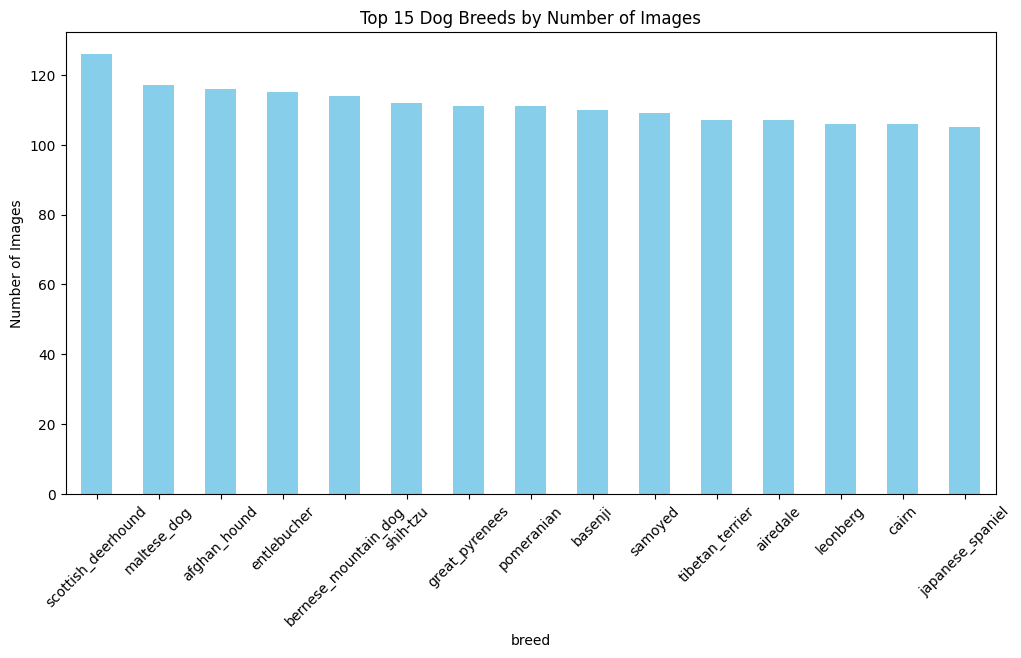

In [ ]:
import matplotlib.pyplot as plt

# Count images per breed
breed_counts = labels_df['breed'].value_counts()

# Plot top 15 breeds
plt.figure(figsize=(12,6))
breed_counts[:15].plot(kind='bar', color='skyblue')
plt.title("Top 15 Dog Breeds by Number of Images")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

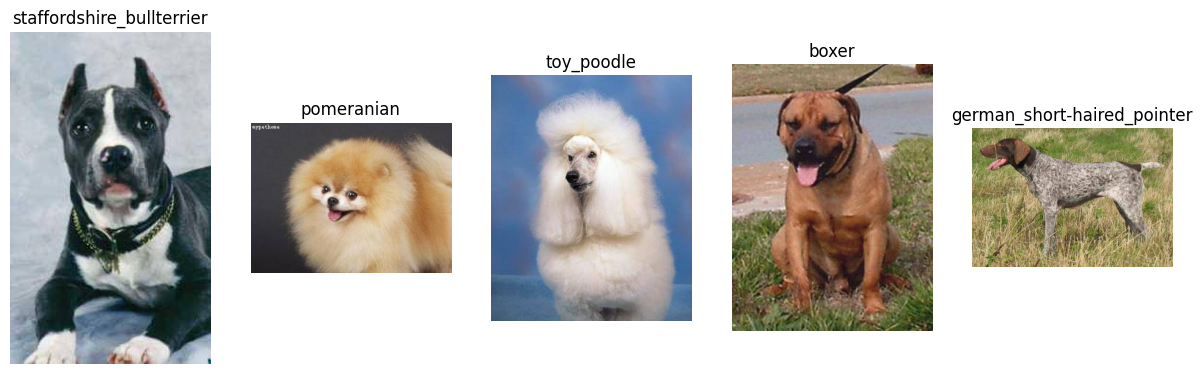

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import os

train_path = "/content/dog_breed_dataset/train"

random_images = random.sample(os.listdir(train_path), 5)

plt.figure(figsize=(15,5))
for i, img_file in enumerate(random_images):
    img_path = os.path.join(train_path, img_file)
    img = mpimg.imread(img_path)

    img_id = os.path.splitext(img_file)[0]
    breed = labels_df[labels_df['id'] == img_id]['breed'].values[0]

    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    plt.title(breed)
    plt.axis('off')

plt.show()

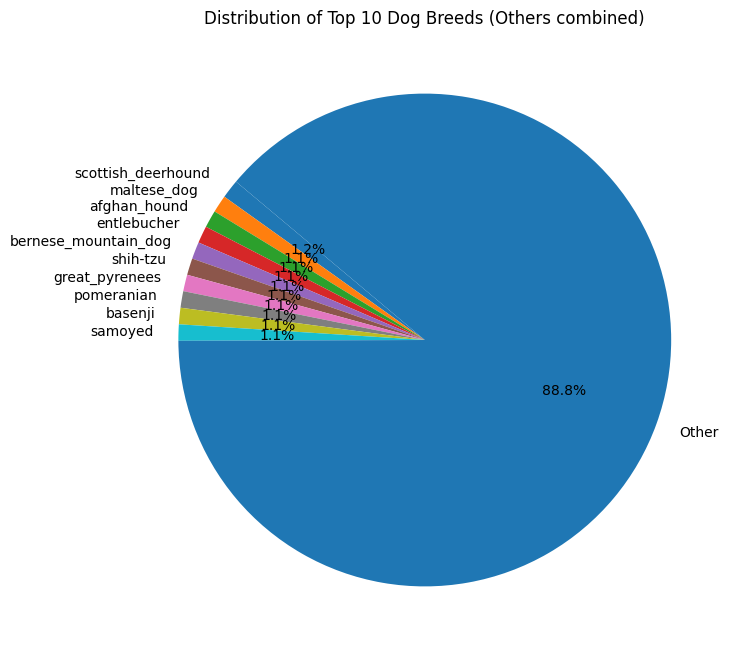

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

breed_counts = labels_df['breed'].value_counts()
top_breeds = breed_counts[:10]
other_count = breed_counts[10:].sum()
pie_counts = pd.concat([top_breeds, pd.Series({'Other': other_count})])

plt.figure(figsize=(8,8))
plt.pie(pie_counts, labels=pie_counts.index, autopct='%1.1f%%', startangle=140)
plt.title("Distribution of Top 10 Dog Breeds (Others combined)")
plt.show()

#**TASK** 2: Downloading and Formatting HUGGING FACE Dataset (20-08-2025)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
project_path = "/content/drive/MyDrive/dog_breed_dataset"
os.makedirs(project_path, exist_ok=True)

In [ ]:
!pip install datasets -q
from datasets import load_dataset
import pandas as pd
import shutil
from PIL import Image
import matplotlib.pyplot as plt

In [ ]:
dataset = load_dataset("Saugatkafley/dog-breed-classification")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/513 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/362M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10222 [00:00<?, ? examples/s]

In [ ]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 10222
    })
})


In [ ]:
train_data = dataset["train"]

In [ ]:
unique_labels = sorted(set(train_data["label"]))

label_names = [str(l) for l in unique_labels]  # fallback: just use the numeric label as string

id2label = {i: str(i) for i in unique_labels}
print("Sample id2label mapping:", list(id2label.items())[:10])

Sample id2label mapping: [('affenpinscher', 'affenpinscher'), ('afghan_hound', 'afghan_hound'), ('african_hunting_dog', 'african_hunting_dog'), ('airedale', 'airedale'), ('american_staffordshire_terrier', 'american_staffordshire_terrier'), ('appenzeller', 'appenzeller'), ('australian_terrier', 'australian_terrier'), ('basenji', 'basenji'), ('basset', 'basset'), ('beagle', 'beagle')]


In [ ]:
labels = []

for idx, example in enumerate(train_data):
    img = example['image']
    label_name = example['label']

    filename = f"train_{idx}.jpg"
    img.save(f"{project_path}/train/{filename}")

    labels.append([filename, label_name])

labels_df = pd.DataFrame(labels, columns=["filename", "label_name"])
labels_csv_path = f"{project_path}/labels.csv"
labels_df.to_csv(labels_csv_path, index=False)

print("✅ Dataset reformatted and saved to Google Drive at:", project_path)

✅ Dataset reformatted and saved to Google Drive at: /content/drive/MyDrive/dog_breed_dataset


In [ ]:
print(labels_df.head(10))

      filename          label_name
0  train_0.jpg         boston_bull
1  train_1.jpg               dingo
2  train_2.jpg            pekinese
3  train_3.jpg            bluetick
4  train_4.jpg    golden_retriever
5  train_5.jpg  bedlington_terrier
6  train_6.jpg  bedlington_terrier
7  train_7.jpg              borzoi
8  train_8.jpg             basenji
9  train_9.jpg  scottish_deerhound


In [ ]:
import pandas as pd

labels_df = pd.read_csv("/content/drive/MyDrive/dog_breed_dataset/labels.csv")
print(labels_df.head(20))   # first 20 rows
print("Total images:", len(labels_df))

        filename               label_name
0    train_0.jpg              boston_bull
1    train_1.jpg                    dingo
2    train_2.jpg                 pekinese
3    train_3.jpg                 bluetick
4    train_4.jpg         golden_retriever
5    train_5.jpg       bedlington_terrier
6    train_6.jpg       bedlington_terrier
7    train_7.jpg                   borzoi
8    train_8.jpg                  basenji
9    train_9.jpg       scottish_deerhound
10  train_10.jpg        shetland_sheepdog
11  train_11.jpg             walker_hound
12  train_12.jpg              maltese_dog
13  train_13.jpg                 bluetick
14  train_14.jpg          norfolk_terrier
15  train_15.jpg      african_hunting_dog
16  train_16.jpg  wire-haired_fox_terrier
17  train_17.jpg                  redbone
18  train_18.jpg         lakeland_terrier
19  train_19.jpg                    boxer
Total images: 10222


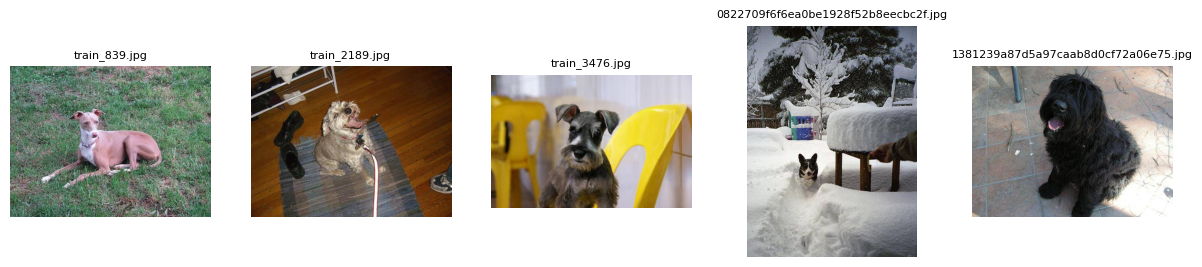

In [ ]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

train_path = "/content/drive/MyDrive/dog_breed_dataset/train"
sample_images = random.sample(os.listdir(train_path), 5)  # 5 random images

fig, axes = plt.subplots(1, 5, figsize=(15,3))
for i, img_file in enumerate(sample_images):
    img = Image.open(os.path.join(train_path, img_file))
    axes[i].imshow(img)
    axes[i].set_title(img_file, fontsize=8)
    axes[i].axis("off")
plt.show()

In [ ]:
import os
import shutil
from tqdm import tqdm

flat_train_path = "/content/drive/MyDrive/dog_breed_dataset/train"
labels_csv_path = "/content/drive/MyDrive/dog_breed_dataset/labels.csv"

structured_base = "/content/drive/MyDrive/dog-breed-classification-dataset"
structured_train = os.path.join(structured_base, "train")
os.makedirs(structured_train, exist_ok=True)

labels_df = pd.read_csv(labels_csv_path)

for _, row in tqdm(labels_df.iterrows(), total=len(labels_df)):
    filename = row["filename"]
    breed = row["label_name"]

    breed_folder = os.path.join(structured_train, breed)
    os.makedirs(breed_folder, exist_ok=True)

    src = os.path.join(flat_train_path, filename)
    dst = os.path.join(breed_folder, filename)

    if os.path.exists(src):
        shutil.copy(src, dst)   # use copy instead of move to keep original safe

shutil.copy(labels_csv_path, os.path.join(structured_base, "labels.csv"))

print("✅ Dataset reorganized into class-wise folders at:", structured_base)
print("Sample breeds:", os.listdir(structured_train)[:10])


100%|██████████| 10222/10222 [02:38<00:00, 64.47it/s]

✅ Dataset reorganized into class-wise folders at: /content/drive/MyDrive/dog-breed-classification-dataset
Sample breeds: ['boston_bull', 'dingo', 'pekinese', 'bluetick', 'golden_retriever', 'bedlington_terrier', 'borzoi', 'basenji', 'scottish_deerhound', 'shetland_sheepdog']


In [ ]:
import os
from collections import Counter

breed_counts = {}
structured_train = "/content/drive/MyDrive/dog-breed-classification-dataset/train"

for breed in os.listdir(structured_train):
    breed_folder = os.path.join(structured_train, breed)
    breed_counts[breed] = len(os.listdir(breed_folder))

for b, c in list(breed_counts.items())[:20]:
    print(f"{b}: {c} images")

print("\nTotal images:", sum(breed_counts.values()))
print("Unique breeds:", len(breed_counts))

boston_bull: 101 images
dingo: 92 images
pekinese: 88 images
bluetick: 97 images
golden_retriever: 80 images
bedlington_terrier: 107 images
borzoi: 89 images
basenji: 130 images
scottish_deerhound: 146 images
shetland_sheepdog: 89 images
walker_hound: 84 images
maltese_dog: 134 images
norfolk_terrier: 94 images
african_hunting_dog: 97 images
wire-haired_fox_terrier: 90 images
redbone: 88 images
lakeland_terrier: 118 images
boxer: 85 images
doberman: 83 images
otterhound: 78 images

Total images: 11824
Unique breeds: 120


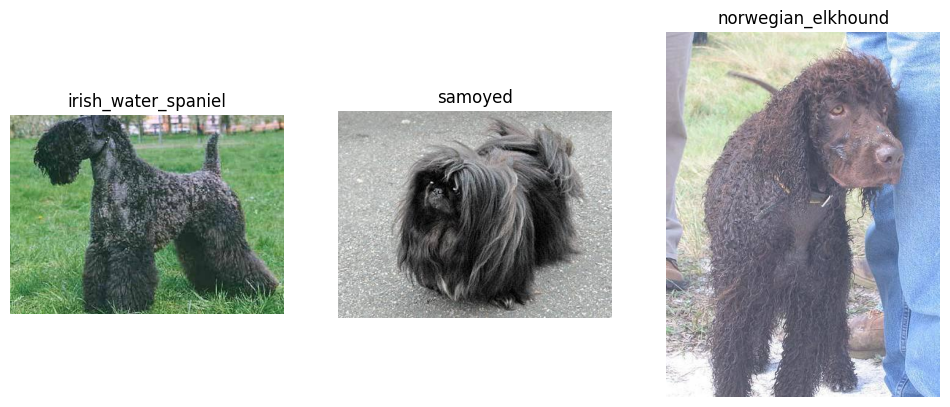

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image

sample_breeds = random.sample(os.listdir(structured_train), 3)

plt.figure(figsize=(12,6))
for i, breed in enumerate(sample_breeds):
    breed_folder = os.path.join(structured_train, breed)
    sample_img = random.choice(os.listdir(breed_folder))
    img_path = os.path.join(breed_folder, sample_img)

    img = Image.open(img_path)

    plt.subplot(1, 3, i+1)
    plt.imshow(img)
    plt.title(breed)
    plt.axis("off")

plt.show()

#**Task** 3 = Dataset analysis → Min/Max/Avg sizes + 3–5 graphs(21-08-25)**bold text**

In [ ]:
import os
import cv2
import numpy as np
import random

train_path = "/content/drive/MyDrive/dog-breed-classification-dataset/train"
test_path  = "/content/drive/MyDrive/dog-breed-classification-dataset/test"

def get_image_sizes(folder, sample_size=2000):
    all_files = []
    for subfolder, _, files in os.walk(folder):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                all_files.append(os.path.join(subfolder, file))

    if len(all_files) == 0:
        return np.array([]), np.array([])

    sample_files = random.sample(all_files, min(sample_size, len(all_files)))

    widths, heights = [], []
    for f in sample_files:
        try:
            img = cv2.imread(f)
            if img is not None:
                h, w = img.shape[:2]
                widths.append(w)
                heights.append(h)
        except:
            pass
    return np.array(widths), np.array(heights)

def print_stats(name, w, h):
    if len(w) == 0 or len(h) == 0:
        print(f"\n{name} Dataset: ❌ No valid images found!")
        return
    print(f"\n{name} Dataset (sampled):")
    print(f" Min Width  = {w.min()}, Min Height = {h.min()}")
    print(f" Max Width  = {w.max()}, Max Height = {h.max()}")
    print(f" Avg Width  = {w.mean():.2f}, Avg Height = {h.mean():.2f}")

train_w, train_h = get_image_sizes(train_path, sample_size=2000)
test_w, test_h   = get_image_sizes(test_path, sample_size=2000)

print_stats("Train", train_w, train_h)
print_stats("Test", test_w, test_h)



Train Dataset (sampled):
 Min Width  = 103, Min Height = 120
 Max Width  = 2272, Max Height = 1910
 Avg Width  = 446.19, Avg Height = 386.73

Test Dataset: ❌ No valid images found!


In [ ]:
import os
import cv2
import numpy as np
import random

train_path = "/content/drive/MyDrive/dog_breed_dataset/train"
test_path  = "/content/drive/MyDrive/dog_breed_dataset/test"

def get_image_sizes(folder, sample_size=2000):
    all_files = []
    for subfolder, _, files in os.walk(folder):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                all_files.append(os.path.join(subfolder, file))

    if len(all_files) == 0:
        return np.array([]), np.array([])

    sample_files = random.sample(all_files, min(sample_size, len(all_files)))

    widths, heights = [], []
    for f in sample_files:
        try:
            img = cv2.imread(f)
            if img is not None:
                h, w = img.shape[:2]
                widths.append(w)
                heights.append(h)
        except:
            pass
    return np.array(widths), np.array(heights)

def print_stats(name, w, h):
    if len(w) == 0 or len(h) == 0:
        print(f"\n{name} Dataset: ❌ No valid images found!")
        return
    print(f"\n{name} Dataset (sampled):")
    print(f" Min Width  = {w.min()}, Min Height = {h.min()}")
    print(f" Max Width  = {w.max()}, Max Height = {h.max()}")
    print(f" Avg Width  = {w.mean():.2f}, Avg Height = {h.mean():.2f}")

train_w, train_h = get_image_sizes(train_path, sample_size=2000)
test_w, test_h   = get_image_sizes(test_path, sample_size=2000)

print_stats("Train", train_w, train_h)
print_stats("Test", test_w, test_h)

In [ ]:
import os

# Check what folders exist in root
print("Root contents:", os.listdir("/content"))

# If you mounted Google Drive earlier
if os.path.exists("/content/drive"):
    print("\nDrive contents:", os.listdir("/content/drive/MyDrive")[:20])

Root contents: ['.config', 'drive', 'sample_data']

Drive contents: ['infosys.ipynb', 'Screenshot_20230514-125138_1 (1).png', 'EwS.jpg', 'Screenshot_20230514-125138_1.png', 'income ', 'ID vasv.pdf', 'Distance using structures .gdoc', 'C game random number .gdoc', 'C project new.gdoc', 'acknowledgement-1704900046552.pdf', 'IMG-20240125-WA0003.jpg', 'Blog 1.gdoc', 'IMG-20240315-WA0026.jpg', 'Screenshot_20240322_140553_WhatsApp.jpg', 'Untitled document (3).gdoc', 'Msme_project.docx', 'msme_project.docx', 'DOC-20241009-WA0002.gdoc', 'DOC-20241009-WA0002.docx', 'MsmeProjectt (2).gdoc']


In [ ]:
import os

dataset_name = "dog_breed_dataset"
found_paths = []

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if dataset_name in dirs:
        found_paths.append(os.path.join(root, dataset_name))

print("Found paths:", found_paths)

Found paths: ['/content/drive/MyDrive/dog_breed_dataset']


In [ ]:
import os
import random
from PIL import Image
import numpy as np

# set dataset base folder
base_dir = "/content/drive/MyDrive/dog_breed_dataset"

# helper function to compute stats
def get_image_stats(folder, sample_size=3000):
    widths, heights = [], []

    # collect all images
    all_files = [os.path.join(folder, f) for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    if len(all_files) == 0:
        return None  # no images found

    # sample if too many
    if len(all_files) > sample_size:
        all_files = random.sample(all_files, sample_size)

    # read dimensions
    for file in all_files:
        try:
            with Image.open(file) as img:
                w, h = img.size
                widths.append(w)
                heights.append(h)
        except:
            continue

    return {
        "count": len(widths),
        "min_width": int(np.min(widths)),
        "min_height": int(np.min(heights)),
        "max_width": int(np.max(widths)),
        "max_height": int(np.max(heights)),
        "avg_width": round(np.mean(widths), 2),
        "avg_height": round(np.mean(heights), 2)
    }

# check if dataset has train/test folders
train_dir = os.path.join(base_dir, "train")
test_dir  = os.path.join(base_dir, "test")

if os.path.exists(train_dir):
    train_stats = get_image_stats(train_dir)
    print("Train Dataset Stats:", train_stats)
else:
    print("⚠️ No 'train' folder found inside dataset")

if os.path.exists(test_dir):
    test_stats = get_image_stats(test_dir)
    print("Test Dataset Stats:", test_stats)
else:
    print("⚠️ No 'test' folder found inside dataset")

# fallback: analyze entire dataset if no train/test
if not os.path.exists(train_dir) and not os.path.exists(test_dir):
    dataset_stats = get_image_stats(base_dir)
    print("Whole Dataset Stats:", dataset_stats)

Train Dataset Stats: {'count': 3000, 'min_width': 112, 'min_height': 111, 'max_width': 2740, 'max_height': 2562, 'avg_width': np.float64(440.33), 'avg_height': np.float64(384.7)}
Test Dataset Stats: {'count': 3000, 'min_width': 100, 'min_height': 100, 'max_width': 2160, 'max_height': 1693, 'avg_width': np.float64(441.76), 'avg_height': np.float64(385.19)}


In [ ]:
import pandas as pd

# Load labels.csv
labels_path = "/content/drive/MyDrive/dog_breed_dataset/labels.csv"
labels_df = pd.read_csv(labels_path)

print("Columns in labels.csv:", labels_df.columns.tolist())
print(labels_df.head())

Columns in labels.csv: ['filename', 'label_name']
      filename        label_name
0  train_0.jpg       boston_bull
1  train_1.jpg             dingo
2  train_2.jpg          pekinese
3  train_3.jpg          bluetick
4  train_4.jpg  golden_retriever


In [ ]:
import pandas as pd

# Paths
train_csv = "/content/drive/MyDrive/dog_breed_dataset/labels.csv"
train_dir = "/content/drive/MyDrive/dog_breed_dataset/train"
test_dir = "/content/drive/MyDrive/dog_breed_dataset/test"

# Read labels file
labels_df = pd.read_csv(train_csv)
print(labels_df.head())

      filename        label_name
0  train_0.jpg       boston_bull
1  train_1.jpg             dingo
2  train_2.jpg          pekinese
3  train_3.jpg          bluetick
4  train_4.jpg  golden_retriever


In [ ]:
import pandas as pd

labels_path = "/content/drive/MyDrive/dog_breed_dataset/labels.csv"
labels_df = pd.read_csv(labels_path)

print("Columns available in labels.csv:", labels_df.columns.tolist())
print("\nFirst 5 rows:\n", labels_df.head())

Columns available in labels.csv: ['filename', 'label_name']

First 5 rows:
       filename        label_name
0  train_0.jpg       boston_bull
1  train_1.jpg             dingo
2  train_2.jpg          pekinese
3  train_3.jpg          bluetick
4  train_4.jpg  golden_retriever


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Path to labels file
labels_path = "/content/drive/MyDrive/dog_breed_dataset/labels.csv"
labels_df = pd.read_csv(labels_path)

# The breed column is 'label_name'
breed_col = "label_name"

# Count images per breed
breed_counts = labels_df[breed_col].value_counts()

print("Top 5 breeds:\n", breed_counts.head())

Top 5 breeds:
 label_name
scottish_deerhound      126
maltese_dog             117
afghan_hound            116
entlebucher             115
bernese_mountain_dog    114
Name: count, dtype: int64


/tmp/ipython-input-1470951363.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=breed_counts.head(5).values, y=breed_counts.head(5).index, palette="viridis")


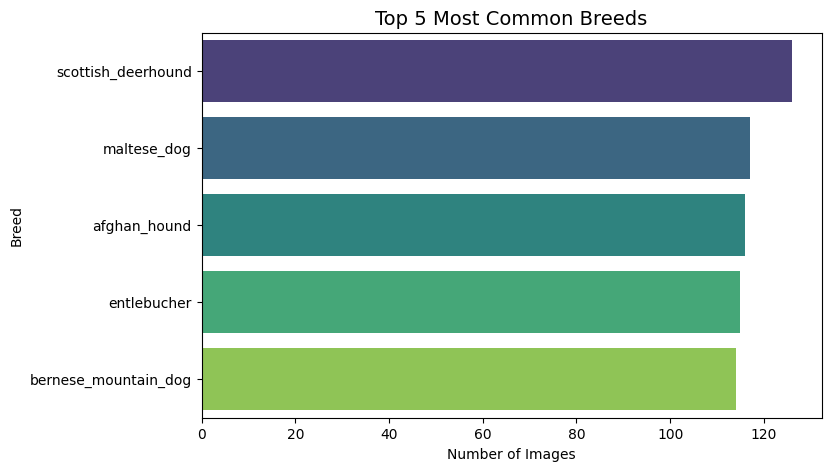

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x=breed_counts.head(5).values, y=breed_counts.head(5).index, palette="viridis")
plt.title("Top 5 Most Common Breeds", fontsize=14)
plt.xlabel("Number of Images")
plt.ylabel("Breed")
plt.show()

/tmp/ipython-input-2278242850.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=breed_counts.tail(5).values, y=breed_counts.tail(5).index, palette="magma")


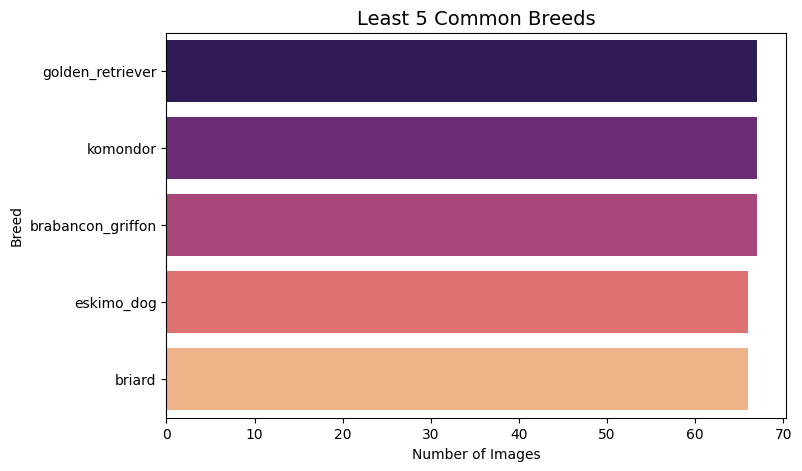

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x=breed_counts.tail(5).values, y=breed_counts.tail(5).index, palette="magma")
plt.title("Least 5 Common Breeds", fontsize=14)
plt.xlabel("Number of Images")
plt.ylabel("Breed")
plt.show()

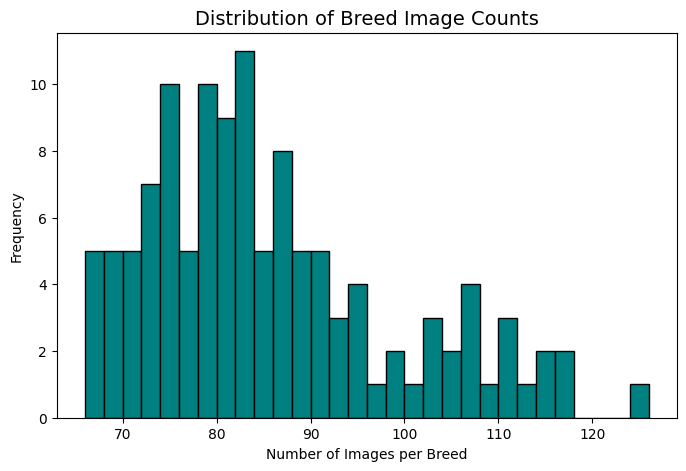

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(breed_counts.values, bins=30, color="teal", edgecolor="black")
plt.title("Distribution of Breed Image Counts", fontsize=14)
plt.xlabel("Number of Images per Breed")
plt.ylabel("Frequency")
plt.show()

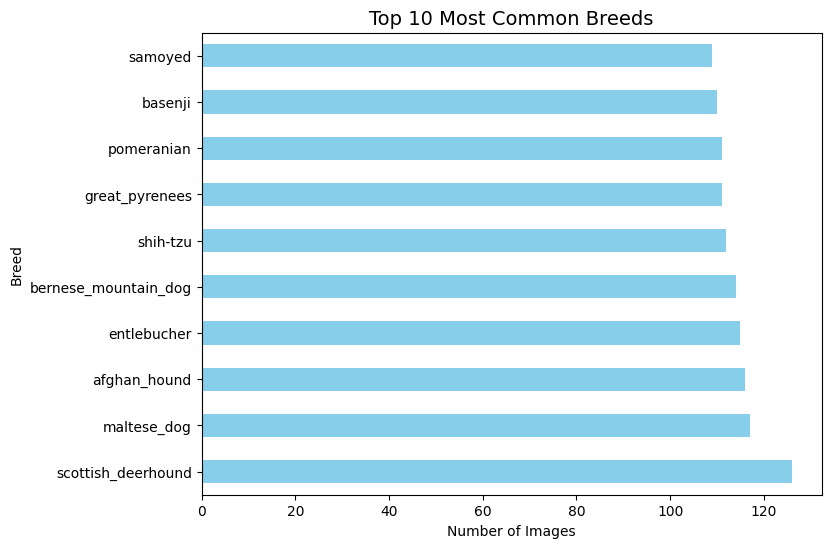

In [ ]:
plt.figure(figsize=(8,6))
breed_counts.head(10).plot(kind="barh", color="skyblue")
plt.title("Top 10 Most Common Breeds", fontsize=14)
plt.xlabel("Number of Images")
plt.ylabel("Breed")
plt.show()

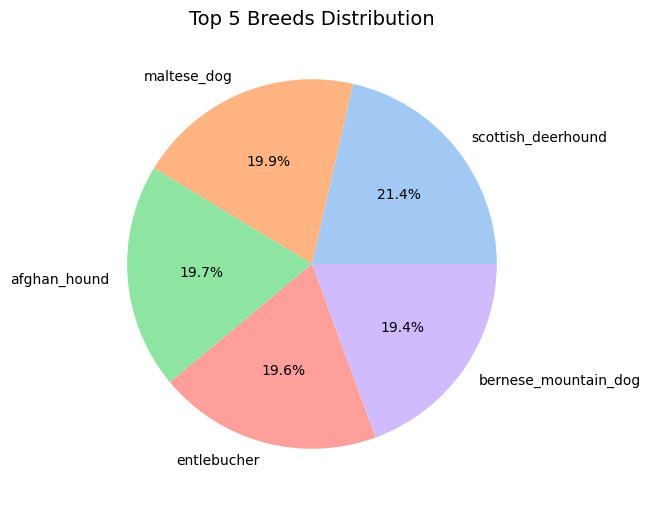

In [ ]:
plt.figure(figsize=(6,6))
plt.pie(breed_counts.head(5).values, labels=breed_counts.head(5).index,
        autopct="%1.1f%%", colors=sns.color_palette("pastel"))
plt.title("Top 5 Breeds Distribution", fontsize=14)
plt.show()

In [ ]:
import os
from PIL import Image
from tqdm import tqdm
import numpy as np

def get_image_stats(folder):
    widths, heights = [], []
    count = 0

    # loop through all image files in folder
    for root, _, files in os.walk(folder):
        for file in files:
            if file.endswith((".jpg", ".png", ".jpeg")):
                path = os.path.join(root, file)
                try:
                    with Image.open(path) as img:
                        w, h = img.size
                        widths.append(w)
                        heights.append(h)
                        count += 1
                except:
                    continue  # skip corrupted files

    stats = {
        "count": count,
        "min_width": int(np.min(widths)),
        "min_height": int(np.min(heights)),
        "max_width": int(np.max(widths)),
        "max_height": int(np.max(heights)),
        "avg_width": float(np.mean(widths)),
        "avg_height": float(np.mean(heights))
    }
    return stats

# paths
train_dir = "/content/drive/MyDrive/dog_breed_dataset/train"
test_dir = "/content/drive/MyDrive/dog_breed_dataset/test"

# compute stats for entire dataset
train_stats = get_image_stats(train_dir)
test_stats = get_image_stats(test_dir)

print("📊 Train Dataset Stats:", train_stats)
print("📊 Test Dataset Stats:", test_stats)

📊 Train Dataset Stats: {'count': 12140, 'min_width': 97, 'min_height': 102, 'max_width': 3264, 'max_height': 2562, 'avg_width': 443.2001647446458, 'avg_height': 386.2472817133443}
📊 Test Dataset Stats: {'count': 10357, 'min_width': 100, 'min_height': 100, 'max_width': 2592, 'max_height': 2560, 'avg_width': 441.7647967558173, 'avg_height': 385.0057931833542}
